`TODO`
- Añadir input binario a BernoulliNB y MultinomialNB.
- Añadir curvas ROC para comparacion entre modelos. 

In [1]:
import re
from typing import Any
import joblib

import pandas as pd
import numpy as np
from nltk import download
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.naive_bayes import (
    MultinomialNB, 
    ComplementNB, 
    BernoulliNB
)
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, 
    precision_score,
    f1_score, 
    recall_score, 
    confusion_matrix
)
from sklearn.model_selection import (
    GridSearchCV, 
    RandomizedSearchCV, 
    ShuffleSplit,
    learning_curve
)
from sklearn.pipeline import Pipeline   

In [2]:
download("punkt", quiet=True)
download("punkt_tab", quiet=True)
download("stopwords", quiet=True)
download("wordnet", quiet=True)

True

In [3]:
df = pd.read_csv(r'../data/Enron_Txt_fn.csv')

In [4]:
df.sample(5)

,label,email,filename
9119,0,['Subject: year end 2000 performance feedback ...,3065.2000-10-30.kaminski.ham.txt
27643,1,"['Subject: cash : $ 293622 \ndear homeowner ,...",3675.2005-07-06.SA_and_HP.spam.txt
12126,0,['Subject: interview schedule for punit rawal ...,4076.2001-01-16.kaminski.ham.txt
26381,1,"[""Subject: we have 1300 softwares for u to dow...",3249.2004-11-23.GP.spam.txt
3502,0,['Subject: f . o . m . nomination eff . june 1...,1171.2000-05-30.farmer.ham.txt


Dado que el dataset Enron es una compilacion de distintos datasets de Spam trae una columna filename, la cual representa el archivo del conjunto de datos de donde proviene el texto como tal.

In [5]:
df.dtypes

label       int64
email         str
filename      str
dtype: object

In [6]:
keep_cols = ['email', 'label']
df = df[keep_cols]

In [7]:
df.isnull().sum()

email    0
label    0
dtype: int64

In [8]:
df['label'].value_counts()

label
1    17171
0    16545
Name: count, dtype: int64

Existe una diferencia muy pequeña (4%) entre correos SPAM y no SPAM. 

In [9]:
df['email'][2]

'[\'Subject: leadership development pilot  \\nsally :\\nwhat timing , ask and you shall receive . as per our discussion , listed below\\nis an update on the leadership pilot . your vendor selection team will\\nreceive an update and even more information later in the week .\\non the lunch & learn for energy operations , the audience and focus will be\\nyour group . we are ready to start up when appropriate .\\nthank you for your time today . please call me if you have any questions at\\nx 33597 .\\n- - - - - - - - - - - - - - - - - - - - - - forwarded by julie armstrong / corp / enron on 01 / 17 / 2000\\n06 : 44 pm - - - - - - - - - - - - - - - - - - - - - - - - - - -\\nfrom : susan runkel @ ect 01 / 17 / 2000 03 : 22 pm\\nto : cindy skinner / hou / ect @ ect , brad mcsherry / hou / ect @ ect , norma\\nvillarreal / hou / ect @ ect , kimberly rizzi / hou / ect @ ect , fran l mayes / hou / ect @ ect ,\\ngary buck / hou / ect @ ect , robert jones / corp / enron @ enron , sheila\\nwalton / 

Vemos que los correos traen cabezeras inutiles para el modelo como Subject o los separadores forward / reply en una sucesion de correos.

# 0. Guardando un 0.02% para despliegue del modelo

In [10]:
df_not_seen = df.sample(frac=0.0002, random_state=42)
df = df.drop(df_not_seen.index)

In [24]:
df_not_seen.to_csv('../data/not_seen_emails.csv', index=False)

# 1. Pre procesamiento

## 1.1 Limpieza de texto de correos

In [12]:
def clean_email(text):
    """Limpieza específica para correos Enron."""
    text = str(text)
    # Remover headers típicos de correo
    text = re.sub(r"Subject:.*?\n", " ", text)
    text = re.sub(r"From:.*?\n", " ", text)
    text = re.sub(r"To:.*?\n", " ", text)
    # Remover separadores de forwarded/reply
    text = re.sub(r"-{3,}.*?-{3,}", " ", text)
    # Remover URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    # Remover emails
    text = re.sub(r"\S+@\S+", " ", text)
    # Remover caracteres especiales y números
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    # Normalizar espacios
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text

In [13]:
df['email_clean'] = df.apply(lambda row: clean_email(row['email']),axis=1)

## 1.2 Tokenizacion, remover stop words y lematizacion

In [14]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

In [15]:
def preprocess(text: str, stop_words: set = stop_words, lemmatizer: Any = lemmatizer):
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)


In [16]:
df['email_tokens'] = df.apply(lambda row: preprocess(row['email_clean']), axis=1)

## 1.3 

## 1.4 N gramas y TF-IDF

In [17]:
grams = (1,2)
max_features = 50000

vectorizer = TfidfVectorizer(
        ngram_range=grams,
        max_features=max_features,
        sublinear_tf=True  # 1 + log(tf)
)

El parametro max_features filtra la cantidad de n-gramas de todo el corpus para dejar solo los n n-gramas que mas se repiten dentro de todo el corups, esto quiere decir que max_features = 50, nos dejaria con los 50 n-gramas que mas se repiten dentro de todo el conjunto de datos de correos. 

### 1.4.1 Miremos los n-gramas formados para algunos correos

In [18]:
vectorizer_explore = TfidfVectorizer(ngram_range=grams, max_features=max_features, sublinear_tf=True)

n_grams = vectorizer_explore.fit_transform(df['email_tokens'])

In [19]:
vocab = vectorizer_explore.get_feature_names_out()
mails = [1000, 7000]

for mail in mails:
    tokens = df['email_tokens'].iloc[mail]
    vector = vectorizer_explore.transform([tokens])
    positions = vector.nonzero()[1]
    tfidf_weights = vector.data

    n_grams = pd.DataFrame({
        "ngram": vocab[positions],
        "tfidf_weight": tfidf_weights
    }).sort_values("tfidf_weight", ascending=False)

    print(f"Correo #{mail}")
    print(f"Tokens: {df['email_tokens'].iloc[mail]}")
    print(n_grams.to_string(index=False))
    print(f"{'='*20}")



Correo #1000
Tokens: subject fyi color copier nkevin nupdate one vendor provided enough information give apple apple comparison sent urgent mail message nfor provide clarification point nall well info sometime monday nvendor mentioned get back monday send nthe quote file danka nthanks patience iain niain russell nto kevin moore hou ect ect ncc vince kaminski hou ect ect mike robert hou ect ect shirley ncrenshaw hou ect ect carole rogers epsc hou ect ect nsubject color copier nkevin sent request vendor provide quote color ncopier equipment available contact soon receive bid nthanks iain nkevin moore nto iain russell epsc hou ect ect vince kaminski hou ect ect mike nroberts hou ect ect shirley crenshaw hou ect ect ncc nsubject color copier nhello iain need expertise nour department need color ncopier nwe need color copier handle nour daily work load nthis printer use research nthe trading floor na may already know use lot map ncharts graph etc nplease inform soon possible nthanks nkevin 

## 1.5 Train test split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    df['email_tokens'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)

In [23]:
X_train_vector, X_test_vector = vectorizer.fit_transform(X_train), vectorizer.transform(X_test)

# 2. Naive Bayes

## 2.1 Multinomial vs Complement vs Bernoulli

In [22]:
models = {
    'MultinomialNB': (MultinomialNB(alpha=0.1), X_train_vector),
    'ComplementNB': (ComplementNB(alpha=0.1), X_train_vector),
    'BernoulliNB': (BernoulliNB(alpha=0.1), (X_train_vector > 0).astype(int))
}

In [23]:
metrics = ['accuracy', 'precision', 'recall', 'f1']

In [24]:
results = []

for model_name, (model, X) in models.items():
    scores = cross_validate(model, X, y_train, cv=10, scoring=metrics, return_train_score=True)

    row = {'model': model_name}
    for metric in metrics:
        train, test = scores[f"train_{metric}"].mean(), scores[f"test_{metric}"].mean()
        percentual_diff  = ((train - test) / train) * 100  

        row[f"{metric}_train"] = train
        row[f"{metric}_test"]  = test
        row[f"{metric}_diff%"] = percentual_diff
    
    results.append(row)

df_cv = pd.DataFrame(results).set_index("model").round(4)

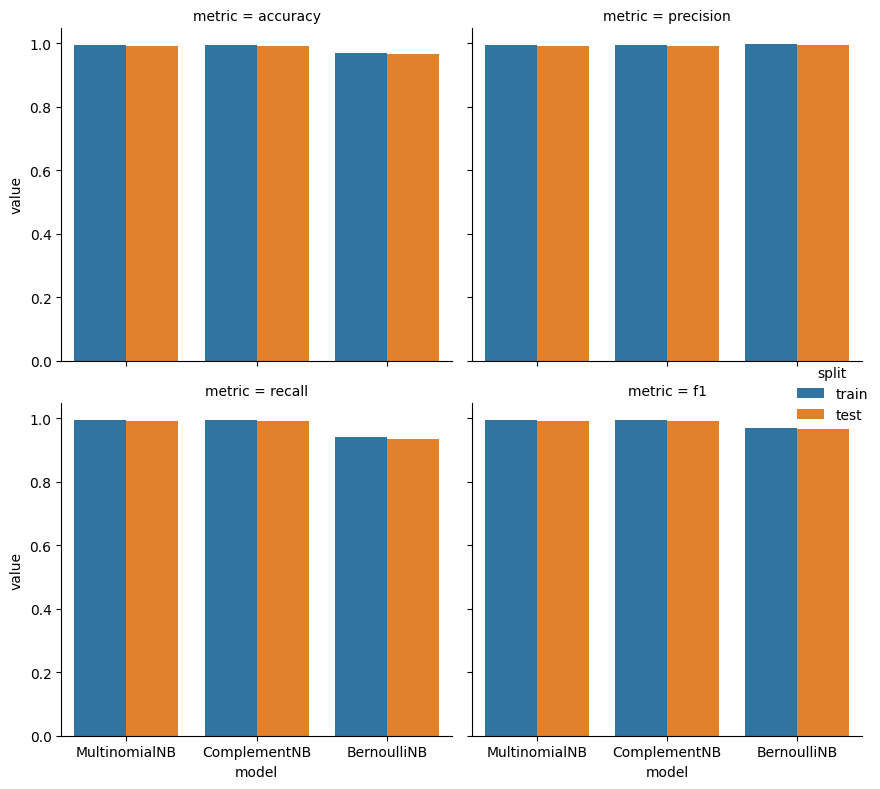

In [25]:
plot_rows = []

for model in df_cv.index:
    for metrica in metrics:
        plot_rows.append({"model": model, "metric": metrica, "split": "train", "value": df_cv.loc[model, f"{metrica}_train"]})
        plot_rows.append({"model": model, "metric": metrica, "split": "test",  "value": df_cv.loc[model, f"{metrica}_test"]})

sns.catplot(
    data=pd.DataFrame(plot_rows),
    kind="bar",
    x="model", y="value", hue="split",
    col="metric", col_wrap=2,        # ← esto hace la matriz 2x2
    height=4, aspect=1.0
)
plt.tight_layout()
plt.show()

## 2.2 Multinomial NB

### 2.2.1 Baseline

In [26]:
nb_model = MultinomialNB(alpha=0.01)

nb_model.fit(X_train_vector, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.01
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [27]:
y_train_pred = nb_model.predict(X_train_vector).flatten()
y_test_pred = nb_model.predict(X_test_vector).flatten()

accuracy_train = accuracy_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred)
f1_train = f1_score(y_train, y_train_pred)
recall_train = recall_score(y_train, y_train_pred)

accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)

print(f"{'Metric':<10} {'Train':>12} {'Test':>12} {'Diff %':>10}")
print(f"{'Accuracy':<10} {accuracy_train:>12.4f} {accuracy_test:>12.4f} {((accuracy_train - accuracy_test) / accuracy_train) * 100:>10.2f}%")
print(f"{'Pecision':<10} {precision_train:>12.4f} {precision_test:>12.4f} {((precision_train - precision_test) / precision_train) * 100:>10.2f}%")
print(f"{'F1':<10} {f1_train:>12.4f} {f1_test:>12.4f} {((f1_train - f1_test) / f1_train) * 100:>10.2f}%")
print(f"{'Recall':<10} {recall_train:>12.4f} {recall_test:>12.4f} {((recall_train - recall_test) / recall_train) * 100:>10.2f}%")

Metric            Train         Test     Diff %
Accuracy         0.9942       0.9899       0.43%
Pecision         0.9932       0.9884       0.49%
F1               0.9943       0.9901       0.42%
Recall           0.9954       0.9918       0.36%


In [28]:
confusion_matrix(y_test, y_test_pred)

array([[3268,   40],
       [  28, 3406]])

### 2.2.2 Busqueda de mejores hiper parametros

In [29]:
param_grid = {
    "alpha":       [0.001, 0.01, 0.1, 0.5, 1.0],
    "class_prior": [None, [0.3, 0.7], [0.2, 0.8]]
}

metric = "recall"

In [30]:
grid = GridSearchCV(
    MultinomialNB(),
    param_grid,
    cv =10,
    scoring=metric,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_vector, y_train)

Fitting 10 folds for each of 15 candidates, totalling 150 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MultinomialNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...], 'class_prior': [None, [0.3, 0.7], ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 

In [31]:
print(f"{'Best params':<10} {grid.best_params_}")
print(f"{f'Best {metric}':<10} {grid.best_score_}")

Best params {'alpha': 1.0, 'class_prior': [0.2, 0.8]}
Best recall 0.9980340863672552


In [32]:
y_train_pred = grid.predict(X_train_vector).flatten()
y_test_pred = grid.predict(X_test_vector).flatten()

accuracy_train = accuracy_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred)
f1_train = f1_score(y_train, y_train_pred)
recall_train = recall_score(y_train, y_train_pred)

accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)

print(f"{'Metric':<10} {'Train':>12} {'Test':>12} {'Diff %':>10}")
print(f"{'Accuracy':<10} {accuracy_train:>12.4f} {accuracy_test:>12.4f} {((accuracy_train - accuracy_test) / accuracy_train) * 100:>10.2f}%")
print(f"{'Pecision':<10} {precision_train:>12.4f} {precision_test:>12.4f} {((precision_train - precision_test) / precision_train) * 100:>10.2f}%")
print(f"{'F1':<10} {f1_train:>12.4f} {f1_test:>12.4f} {((f1_train - f1_test) / f1_train) * 100:>10.2f}%")
print(f"{'Recall':<10} {recall_train:>12.4f} {recall_test:>12.4f} {((recall_train - recall_test) / recall_train) * 100:>10.2f}%")

Metric            Train         Test     Diff %
Accuracy         0.9868       0.9828       0.40%
Pecision         0.9760       0.9686       0.76%
F1               0.9872       0.9834       0.38%
Recall           0.9985       0.9985      -0.00%


In [33]:
confusion_matrix(y_test, y_test_pred)

array([[3197,  111],
       [   5, 3429]])

## 2.3 Complement NB

### 2.3.1 Baseline

In [34]:
nb_model = ComplementNB(alpha=0.01)

nb_model.fit(X_train_vector, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.01
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueOnly used in edge case with a single class in the training set.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. Not used.",None
,"norm norm: bool, default=FalseWhether or not a second normalization of the weights is performed. Thedefault behavior mirrors the implementations found in Mahout and Weka,which do not follow the full algorithm described in Table 9 of thepaper.",False


In [35]:
y_train_pred = nb_model.predict(X_train_vector).flatten()
y_test_pred = nb_model.predict(X_test_vector).flatten()

accuracy_train = accuracy_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred)
f1_train = f1_score(y_train, y_train_pred)
recall_train = recall_score(y_train, y_train_pred)

accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)

print(f"{'Metric':<10} {'Train':>12} {'Test':>12} {'Diff %':>10}")
print(f"{'Accuracy':<10} {accuracy_train:>12.4f} {accuracy_test:>12.4f} {((accuracy_train - accuracy_test) / accuracy_train) * 100:>10.2f}%")
print(f"{'Pecision':<10} {precision_train:>12.4f} {precision_test:>12.4f} {((precision_train - precision_test) / precision_train) * 100:>10.2f}%")
print(f"{'F1':<10} {f1_train:>12.4f} {f1_test:>12.4f} {((f1_train - f1_test) / f1_train) * 100:>10.2f}%")
print(f"{'Recall':<10} {recall_train:>12.4f} {recall_test:>12.4f} {((recall_train - recall_test) / recall_train) * 100:>10.2f}%")

Metric            Train         Test     Diff %
Accuracy         0.9942       0.9901       0.41%
Pecision         0.9935       0.9887       0.49%
F1               0.9943       0.9903       0.41%
Recall           0.9950       0.9918       0.32%


In [36]:
confusion_matrix(y_test, y_test_pred)

array([[3269,   39],
       [  28, 3406]])

### 2.3.2 Busqueda de mejores hiper parametros

In [37]:
param_grid = {
    "alpha":       [0.001, 0.01, 0.1, 0.5, 1.0],
    "norm":        [True, False],
    "class_prior": [None, [0.3, 0.7], [0.2, 0.8]]
}

metric = "recall"

In [38]:
grid = GridSearchCV(
    ComplementNB(),
    param_grid,
    cv =10,
    scoring=metric,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_vector, y_train)

Fitting 10 folds for each of 30 candidates, totalling 300 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ComplementNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...], 'class_prior': [None, [0.3, 0.7], ...], 'norm': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score i

In [39]:
print(f"{'Best params':<10} {grid.best_params_}")
print(f"{f'Best {metric}':<10} {grid.best_score_}")

Best params {'alpha': 0.01, 'class_prior': None, 'norm': False}
Best recall 0.9916987100994327


In [40]:
y_train_pred = grid.predict(X_train_vector).flatten()
y_test_pred = grid.predict(X_test_vector).flatten()

accuracy_train = accuracy_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred)
f1_train = f1_score(y_train, y_train_pred)
recall_train = recall_score(y_train, y_train_pred)

accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)

print(f"{'Metric':<10} {'Train':>12} {'Test':>12} {'Diff %':>10}")
print(f"{'Accuracy':<10} {accuracy_train:>12.4f} {accuracy_test:>12.4f} {((accuracy_train - accuracy_test) / accuracy_train) * 100:>10.2f}%")
print(f"{'Pecision':<10} {precision_train:>12.4f} {precision_test:>12.4f} {((precision_train - precision_test) / precision_train) * 100:>10.2f}%")
print(f"{'F1':<10} {f1_train:>12.4f} {f1_test:>12.4f} {((f1_train - f1_test) / f1_train) * 100:>10.2f}%")
print(f"{'Recall':<10} {recall_train:>12.4f} {recall_test:>12.4f} {((recall_train - recall_test) / recall_train) * 100:>10.2f}%")

Metric            Train         Test     Diff %
Accuracy         0.9942       0.9901       0.41%
Pecision         0.9935       0.9887       0.49%
F1               0.9943       0.9903       0.41%
Recall           0.9950       0.9918       0.32%


In [41]:
confusion_matrix(y_test, y_test_pred)

array([[3269,   39],
       [  28, 3406]])

# 3. MLP

## 3.1 Baseline MLP

In [42]:
mlp_model = MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation="relu",
        max_iter=15,
        early_stopping=True,
        random_state=42,
        solver="adam",
        momentum=0.9,
        learning_rate_init=0.001,
        learning_rate='adaptive',
        verbose=True,
    )

mlp_model.fit(X_train_vector, y_train)

Iteration 1, loss = 0.12191210
Validation score: 0.990730
Iteration 2, loss = 0.00601318
Validation score: 0.990730
Iteration 3, loss = 0.00203475
Validation score: 0.989618
Iteration 4, loss = 0.00158633
Validation score: 0.991472
Iteration 5, loss = 0.00142763
Validation score: 0.990360
Iteration 6, loss = 0.00135526
Validation score: 0.990730
Iteration 7, loss = 0.00138179
Validation score: 0.991101
Iteration 8, loss = 0.00121815
Validation score: 0.991472
Iteration 9, loss = 0.00116931
Validation score: 0.991843
Iteration 10, loss = 0.00126772
Validation score: 0.990730
Iteration 11, loss = 0.00129494
Validation score: 0.991472
Iteration 12, loss = 0.00106127
Validation score: 0.991843
Iteration 13, loss = 0.00124391
Validation score: 0.991472
Iteration 14, loss = 0.00113630
Validation score: 0.991843
Iteration 15, loss = 0.00110369
Validation score: 0.991843


/Users/spuertaf/Repos/SpamDetectionNaiveBayes/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(256, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'adaptive'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",15
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


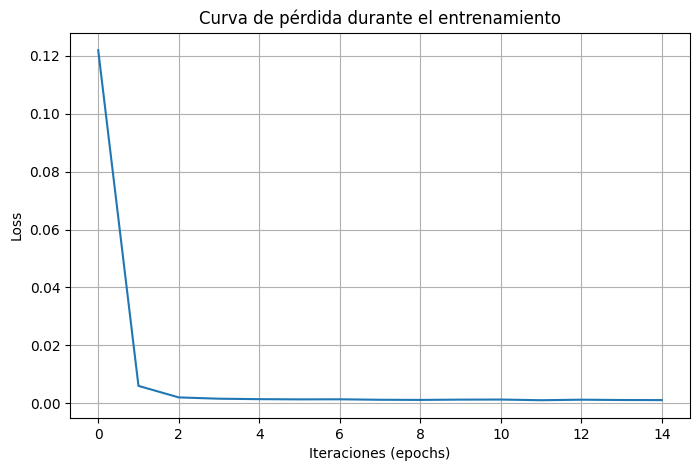

In [43]:
plt.figure(figsize=(8,5))
plt.plot(mlp_model.loss_curve_)
plt.title("Curva de pérdida durante el entrenamiento")
plt.xlabel("Iteraciones (epochs)")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [44]:
y_train_pred = mlp_model.predict(X_train_vector).flatten()
y_test_pred = mlp_model.predict(X_test_vector).flatten()

accuracy_train = accuracy_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred)
f1_train = f1_score(y_train, y_train_pred)
recall_train = recall_score(y_train, y_train_pred)

accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)

print(f"{'Metric':<10} {'Train':>12} {'Test':>12} {'Diff %':>10}")
print(f"{'Accuracy':<10} {accuracy_train:>12.4f} {accuracy_test:>12.4f} {((accuracy_train - accuracy_test) / accuracy_train) * 100:>10.2f}%")
print(f"{'Pecision':<10} {precision_train:>12.4f} {precision_test:>12.4f} {((precision_train - precision_test) / precision_train) * 100:>10.2f}%")
print(f"{'F1':<10} {f1_train:>12.4f} {f1_test:>12.4f} {((f1_train - f1_test) / f1_train) * 100:>10.2f}%")
print(f"{'Recall':<10} {recall_train:>12.4f} {recall_test:>12.4f} {((recall_train - recall_test) / recall_train) * 100:>10.2f}%")

Metric            Train         Test     Diff %
Accuracy         0.9990       0.9930       0.60%
Pecision         0.9988       0.9930       0.58%
F1               0.9991       0.9932       0.59%
Recall           0.9993       0.9933       0.60%


In [45]:
confusion_matrix(y_test, y_test_pred)

array([[3284,   24],
       [  23, 3411]])

## 3.2 Busqueda de mejores hiper parametros

In [46]:
param_dist = {
    "hidden_layer_sizes": [(64,), (128,), (256,), (128, 64), (256, 128)],
    "alpha":              [0.0001, 0.001, 0.01, 0.1],
    "learning_rate_init": [0.0001, 0.001, 0.01],
    "activation":         ["relu", "tanh"],
}

metric = 'recall'

In [47]:
random_search = RandomizedSearchCV(
    MLPClassifier(max_iter=15, early_stopping=True, random_state=42, solver='adam'),
    param_dist,
    n_iter=20,         # ← prueba solo 20 combinaciones aleatorias
    cv=3,
    scoring=metric,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_vector, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/Users/spuertaf/Repos/SpamDetectionNaiveBayes/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/spuertaf/Repos/SpamDetectionNaiveBayes/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/spuertaf/Repos/SpamDetectionNaiveBayes/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/spuertaf/Repos/SpamDetectionNaiveBayes/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iteratio

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'activation': ['relu', 'tanh'], 'alpha': [0.0001, 0.001, ...], 'hidden_layer_sizes': [(64,), (128,), ...], 'learning_rate_init': [0.0001, 0.001, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies tha

In [48]:
print(f"{'Best params':<10} {random_search.best_params_}")
print(f"{f'Best {metric}':<10} {random_search.best_score_}")

Best params {'learning_rate_init': 0.001, 'hidden_layer_sizes': (128,), 'alpha': 0.1, 'activation': 'tanh'}
Best recall 0.9959950855002498


In [49]:
y_train_pred = random_search.predict(X_train_vector).flatten()
y_test_pred = random_search.predict(X_test_vector).flatten()

accuracy_train = accuracy_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred)
f1_train = f1_score(y_train, y_train_pred)
recall_train = recall_score(y_train, y_train_pred)

accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)

print(f"{'Metric':<10} {'Train':>12} {'Test':>12} {'Diff %':>10}")
print(f"{'Accuracy':<10} {accuracy_train:>12.4f} {accuracy_test:>12.4f} {((accuracy_train - accuracy_test) / accuracy_train) * 100:>10.2f}%")
print(f"{'Pecision':<10} {precision_train:>12.4f} {precision_test:>12.4f} {((precision_train - precision_test) / precision_train) * 100:>10.2f}%")
print(f"{'F1':<10} {f1_train:>12.4f} {f1_test:>12.4f} {((f1_train - f1_test) / f1_train) * 100:>10.2f}%")
print(f"{'Recall':<10} {recall_train:>12.4f} {recall_test:>12.4f} {((recall_train - recall_test) / recall_train) * 100:>10.2f}%")

Metric            Train         Test     Diff %
Accuracy         0.9981       0.9929       0.52%
Pecision         0.9977       0.9902       0.75%
F1               0.9981       0.9930       0.51%
Recall           0.9986       0.9959       0.27%


In [50]:
confusion_matrix(y_test, y_test_pred)

array([[3274,   34],
       [  14, 3420]])

# 4. Escalabilidad de los modelos 

In [21]:
chosen_models = {
    "MultinomialNB": MultinomialNB(alpha=1.0, class_prior=[0.2, 0.8]),
    "MLPClassifier": MLPClassifier(
        hidden_layer_sizes=(128),
        max_iter=15,
        early_stopping=True,
        random_state=42,
        learning_rate_init=0.001,
        alpha=0.1,
        activation="tanh",
    ),
}

In [34]:
common_params = {
    "X": X_train_vector,
    "y": y_train,
    "train_sizes": np.linspace(0.6, 1.0, 5),
    "cv": ShuffleSplit(n_splits=10, test_size=0.2, random_state=123),
    "n_jobs": -1,
    "return_times": True,
}

scoring_metric = "recall"

In [35]:
results = {}
for model_name, model in chosen_models.items():
    train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
        model, **common_params, scoring=scoring_metric
    )

    # Calculate the mean and standard deviation of the scores
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Calculate the mean and standard deviation of the fit and score times
    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)
    score_times_mean = np.mean(score_times, axis=1)
    score_times_std = np.std(score_times, axis=1)

    results[model_name] = {
        "train_sizes": train_sizes,
        "train_mean": train_mean,
        "train_std": train_std,
        "test_mean": test_mean,
        "test_std": test_std,
        "fit_times_mean": fit_times_mean,
        "fit_times_std": fit_times_std,
        "score_times_mean": score_times_mean,
        "score_times_std": score_times_std,
    }

/Users/spuertaf/Repos/SpamDetectionNaiveBayes/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/spuertaf/Repos/SpamDetectionNaiveBayes/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/spuertaf/Repos/SpamDetectionNaiveBayes/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/spuertaf/Repos/SpamDetectionNaiveBayes/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iteratio

## 4.1 Learning curve

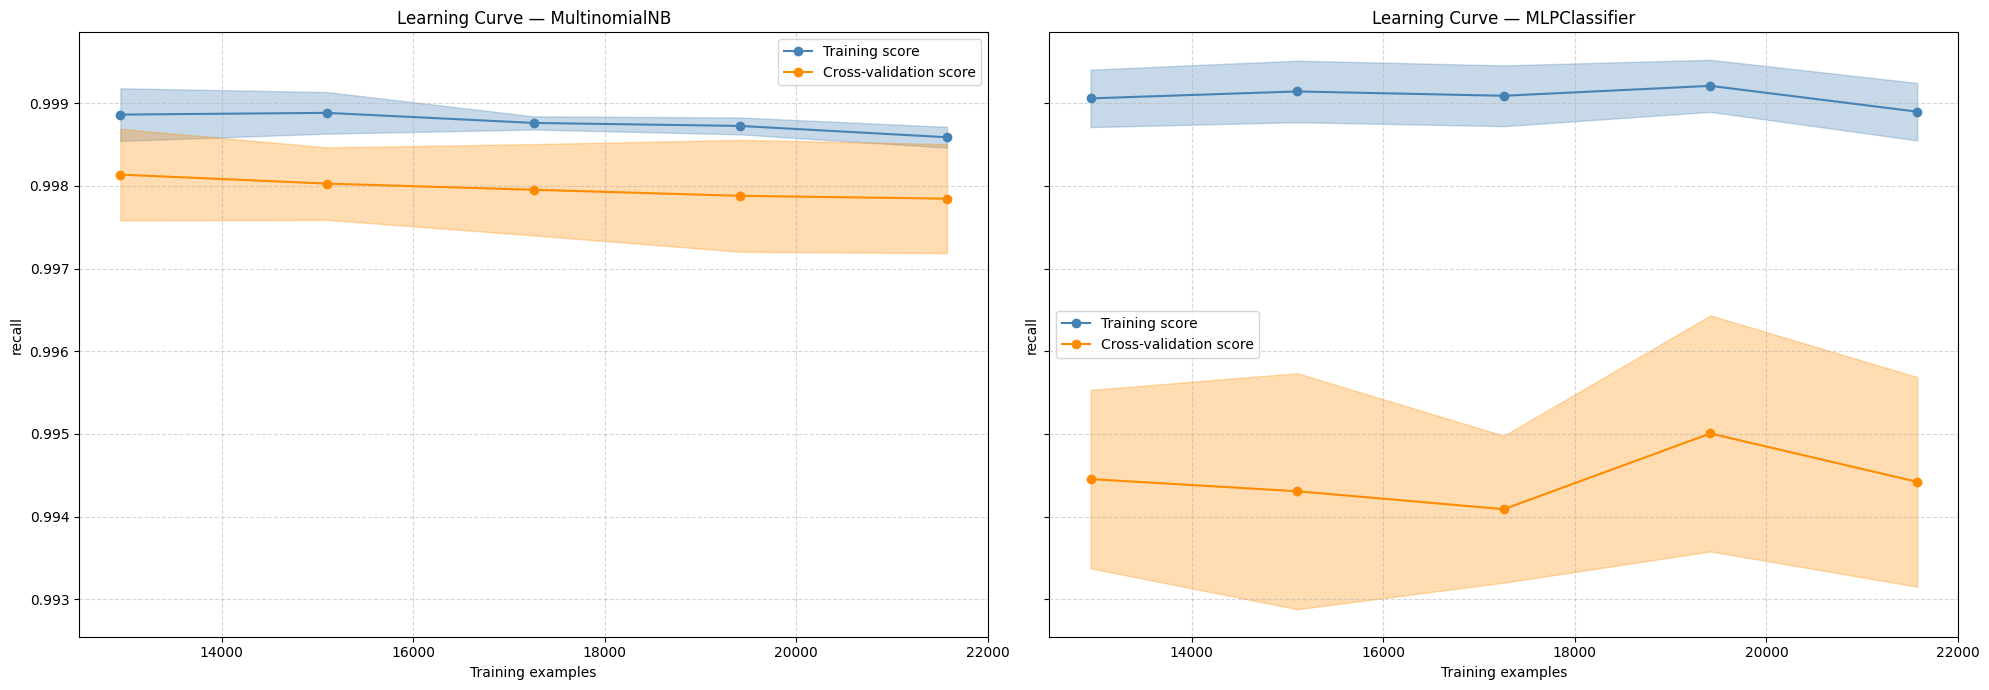

In [38]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 7), sharey=True)

for (model_name, res), ax in zip(results.items(), axes):
    train_sizes = res["train_sizes"]
    train_mean  = res["train_mean"]
    train_std   = res["train_std"]
    test_mean   = res["test_mean"]
    test_std    = res["test_std"]

    # Relleno PRIMERO para que quede detrás de la línea
    ax.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.3,
        color="steelblue",
    )
    ax.fill_between(
        train_sizes,
        test_mean - test_std,
        test_mean + test_std,
        alpha=0.3,
        color="darkorange",
    )

    # Líneas DESPUÉS
    ax.plot(train_sizes, train_mean, "o-", color="steelblue", label="Training score")
    ax.plot(train_sizes, test_mean, "o-", color="darkorange", label="Cross-validation score")

    ax.set_title(f"Learning Curve — {model_name}")
    ax.set_xlabel("Training examples")
    ax.set_ylabel(scoring_metric)
    ax.legend(loc="best")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 4.2 Fit time vs. Inference time

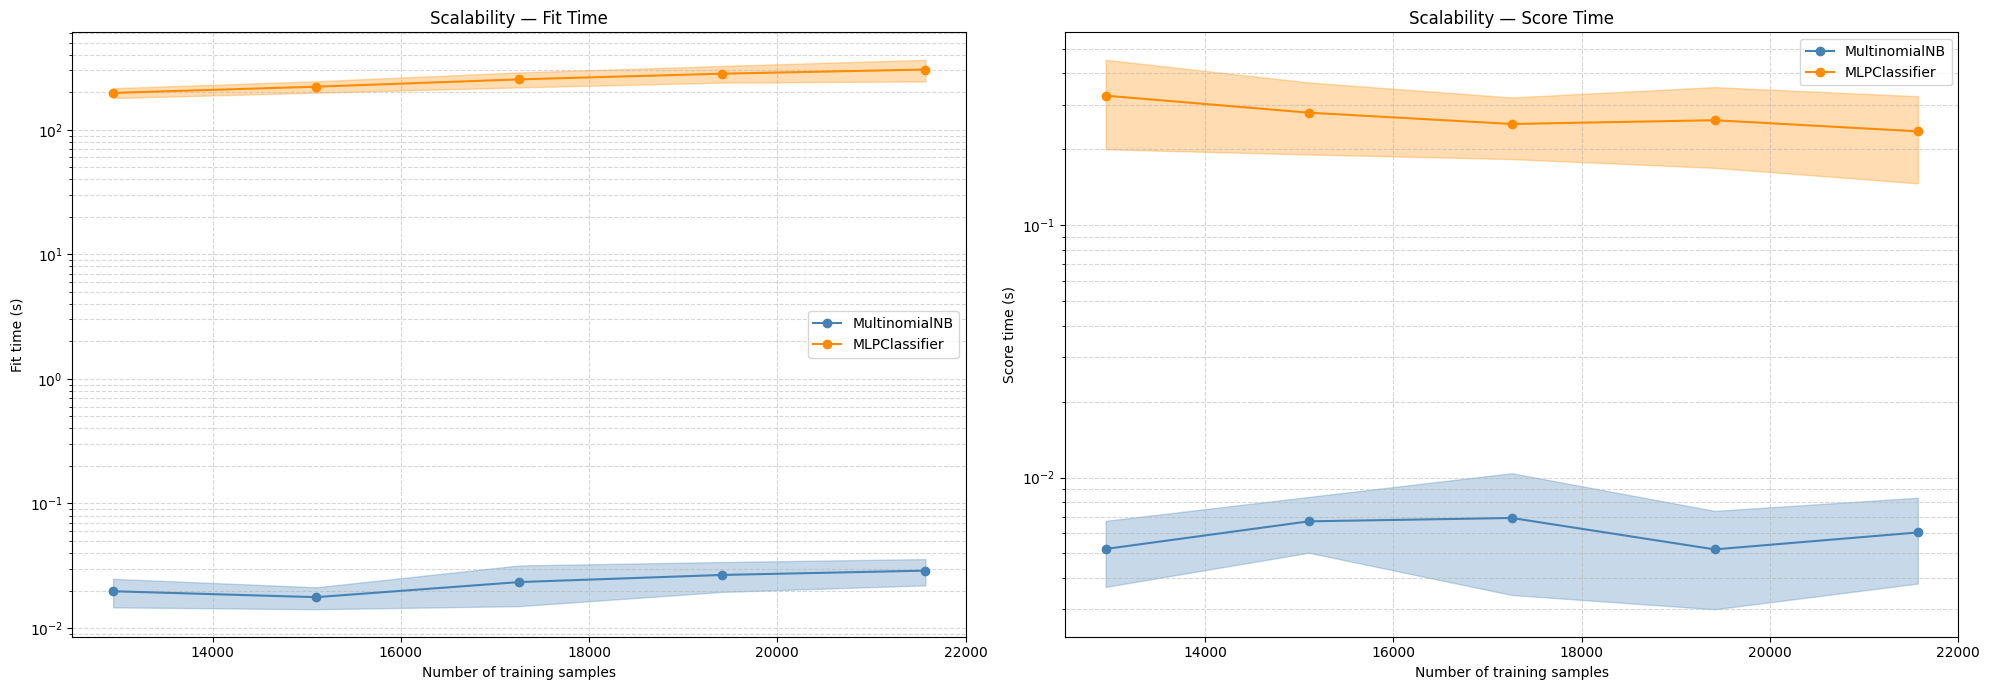

In [37]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 7))

colors = ["steelblue", "darkorange"]

for (model_name, res), color in zip(results.items(), colors):
    train_sizes      = res["train_sizes"]
    fit_times_mean   = res["fit_times_mean"]
    fit_times_std    = res["fit_times_std"]
    score_times_mean = res["score_times_mean"]
    score_times_std  = res["score_times_std"]

    # --- Fit time ---
    axes[0].plot(train_sizes, fit_times_mean, "o-", color=color, label=model_name)
    axes[0].fill_between(
        train_sizes,
        fit_times_mean - fit_times_std,
        fit_times_mean + fit_times_std,
        alpha=0.3,
        color=color,
    )

    # --- Score time ---
    axes[1].plot(train_sizes, score_times_mean, "o-", color=color, label=model_name)
    axes[1].fill_between(
        train_sizes,
        score_times_mean - score_times_std,
        score_times_mean + score_times_std,
        alpha=0.3,
        color=color,
    )

# --- Configuración de ejes ---
for ax in axes:
    ax.set_xlabel("Number of training samples")
    ax.set_yscale("log")   # 👈 escala log para apreciar diferencias de orden de magnitud
    ax.legend()
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

axes[0].set_ylabel("Fit time (s)")
axes[0].set_title("Scalability — Fit Time")
axes[1].set_ylabel("Score time (s)")
axes[1].set_title("Scalability — Score Time")

plt.tight_layout()
plt.show()

# 5. Reentrenamiento final 

In [30]:
X = pd.concat([X_train, X_test])
Y = np.concatenate([y_train, y_test])

In [31]:
pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True)),
    ("model", MultinomialNB(alpha=1.0, class_prior=[0.2, 0.8]))
])

pipeline.fit(X, Y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


# 6. Guardado de modelo

In [32]:
joblib.dump(pipeline, r"../models/nb_pipeline.joblib")

['../models/nb_pipeline.joblib']